# Scalar DM production

This notebook implements (and cleans up) a numerical pipeline inspired by **1006.2518v3** adn **1306.4710v5** for the real singlet scalar DM model:

1. Define the model and parameters.
2. Compute Higgs total width $\Gamma_h(\lambda,m_D)$ including $h\to SS$ when open.
3. Compute reduced annihilation cross sections $\hat\sigma(s)$ for $SS\to f\bar f,\ WW,\ ZZ,\ hh$.
4. Compute the thermal average $\langle\sigma v\rangle(x)$ with a numerically stable integral.
5. Solve the Boltzmann equation for the yield $Y(x)$.
6. For each $m_D$, solve for $\lambda$ such that $\Omega_D h^2 \approx 0.11$.
7. Produce the main diagnostic plots (similar to Fig. 1, 3, 4).

**Conventions**
- Units: **GeV** throughout.
- Natural units $\hbar=c=1$: $\langle\sigma v\rangle$ is in **$\text{GeV}^{-2}$**.
- We provide explicit conversion to **$\text{cm}^3$/s** for indirect detection plots.


### Necessary imports to run the notebook

In [321]:
!pip install particle
!pip install shapely
!pip install joblib tqdm

In [322]:
#To get the masses
from particle import Particle
#To compute thermal avg cs
import numpy as np
import scipy as scp
from scipy.special import kve
#To solve Boltzmann equation
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
#To visualize results
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator
from shapely.geometry import LineString
from pathlib import Path
import pandas as pd
import warnings
import os
# to multiprocesses
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import contextlib
import joblib

In [323]:
# --- SM masses in GeV ---
m_n = 0.9395654133  # nucleon mass 

# --- Boson masses ---
m_h = 125.20  # Higgs mass in GeV
m_w = Particle.from_evtgen_name("W+").mass * 1e-3
m_z = Particle.from_evtgen_name("Z0").mass * 1e-3

# --- Fermion masses ---
m_e   = Particle.from_evtgen_name("e-").mass   * 1e-3
m_mu  = Particle.from_evtgen_name("mu-").mass  * 1e-3
m_tau = Particle.from_evtgen_name("tau-").mass * 1e-3

# --- Quark masses ---
m_qu = Particle.from_evtgen_name("u").mass * 1e-3
m_qd = Particle.from_evtgen_name("d").mass * 1e-3
m_qs = Particle.from_evtgen_name("s").mass * 1e-3
m_qc = Particle.from_evtgen_name("c").mass * 1e-3
m_qb = Particle.from_evtgen_name("b").mass * 1e-3
m_qt = Particle.from_evtgen_name("t").mass * 1e-3

SM_leptons = [m_e, m_mu, m_tau]                    # charged leptons
SM_quarks  = [m_qu, m_qd, m_qs, m_qc, m_qb, m_qt]   # quarks (we include 3 colors in rates)

# --- Other constants ---
vev  = 246.2           # Higgs vev in GeV
m_pl = 1.2209e19       # Planck mass in GeV
alpha_s = 0.12         # Strong Coupling constant
Br_inv_limit = 0.107   # Retrived from PDG

# --- Unit conversion: (cm^3/s) <-> (GeV^-2) ---
CM_TO_GEV_INV = 5.0677307e13   # 1 cm  = 5.0677e13 GeV^-1
S_TO_GEV_INV  = 1.5192674e24   # 1 s   = 1.5193e24 GeV^-1
CM3_PER_S_TO_GEV_M2 = (CM_TO_GEV_INV**3) / S_TO_GEV_INV  # (cm^3/s) -> (GeV^-2)
GEV_M2_TO_CM3_PER_S = 1.0 / CM3_PER_S_TO_GEV_M2          # (GeV^-2) -> (cm^3/s)

print(f"Conversion: 1 GeV^-2 = {GEV_M2_TO_CM3_PER_S:.3e} cm^3/s")
# --- Data to extrapole Higgs total decay width in GeV---
s_data_1 = np.arange(90, 200, 5, dtype=float)
s_data_2 = np.arange(200, 1010, 10, dtype=float)
s_data = np.concatenate((s_data_1,s_data_2))


width_data = np.array([2.20*1E-3,2.32*1E-3,2.46*1E-3,2.62*1E-3,2.82*1E-3,3.09*1E-3,3.47*1E-3,4.03*1E-3,4.87*1E-3,6.14*1E-3,8.12*1E-3,1.14*1E-2,1.73*1E-2,3.02*1E-2,8.29*1E-2,2.46*1E-1,3.80*1E-1,5.00*1E-1,6.31*1E-1,8.39*1E-1,1.04,1.24,1.43,1.85,
              2.31,2.82,3.40,4.04,4.76,5.55,6.43,7.39,8.43,9.57,10.8,12.1,13.5,15.2,17.6,20.2,23.1,26.1,29.2,32.5,35.9,39.4,43.1,46.9,50.8,54.9,59.1,63.5,68,72.7,77.6,82.6,87.7,93.1,98.7,104,110,116,123,129,136,143,150,158,166,174,182,
              190,199,208,218,227,237,248,258,269,281,292,304,317,330,343,357,371,386,401,416,432,449,466,484,502,521,540,560,581,602,624,647])

SM_width = PchipInterpolator(s_data,width_data)


# --- Data to extrapole Degrees of freedom in GeV---
T_data = np.array([10e3,5e3,2e3,1e3,500,200,100,50,20,10,5,2,1,0.5,0.214,0.2139999,0.200,0.190,0.180,0.170,0.16999999,0.160,0.150,0.149999,0.140,0.130,0.100,0.050,0.020,0.010,0.005, 0.002,0.001,500e-6,200e-6,100e-6,50e-6,20e-6,10e-6])
g_star_s_data = np.array([106.75,106.75,106.74,106.70, 106.56,105.61,102.85, 96.53, 88.14, 86.13,85.37,81.80, 75.50,68.55,62.25,62.25,61.99, 61.83, 61.67,61.52, 61.52,61.38, 61.25, 24.77,22.59,20.86,17.55,14.32, 11.25, 10.76, 10.74,10.70,10.56,10.03, 7.55, 4.78,3.93,3.91,3.91])
g_star_energy_density_data = np.array([106.75,106.75,106.74,106.72,106.61,105.90,103.53,97.40,88.45,86.22,85.60,82.50,76.34,69.26,62.49,62.49,62.21,62.03,61.87,61.72,61.72,61.58,61.45,26.32,23.77,21.76,18.00,14.63,11.33,10.76,10.74,10.71,10.60,10.16,7.66,4.46,3.39,3.36, 3.36])

# --- Reversing order to use PchipInterpolator
T_data = T_data[::-1]
g_star_s_data = g_star_s_data[::-1]
g_star_energy_density_data = g_star_energy_density_data[::-1]

# --- Convert to Log for numerical stability in the QCD transition
log_T = np.log10(T_data)
log_h = np.log10(g_star_s_data)
log_g = np.log10(g_star_energy_density_data)

# Create Splines
h_eff_log = PchipInterpolator(log_T, log_h) #entropy
g_eff_log = PchipInterpolator(log_T, log_g) #energy

# ---Saving Plots-----
base_dir = Path.cwd().parent

Conversion: 1 GeV^-2 = 1.167e-17 cm^3/s


In [324]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# Relic abundance calculation

The usual **Boltzmann equation** for the yield $Y = n/s$:

$$
\frac{dY}{dx} = -\frac{s(x)}{x H(x)}\langle \sigma v \rangle \left(Y^2 - Y_{\rm eq}^2\right),
$$

with $x = m_D/T$.

We define:

* $H(x)$ using $H(T) = \sqrt{\frac{4\pi^3 g_*}{45}}\,\frac{T^2}{M_{\rm Pl}}$ with $T = m_D/x$.
* $s(x)$ using $s(T) = \frac{2\pi^2}{45} g_* T^3$.
* $Y_{\rm eq}(x) = n_{\rm eq}(x) / s(x)$, with $n_{\rm eq}$ using `n_eq_scaled` and our $e^{-x}$ factor.

For a given mass $m_D$ and coupling $\lambda$, we:

1. Precompute `sigma_interp = interpol_sigma(lamb, m_d, x_ini, x_max)`.
2. Solve the ODE from $x_{\rm ini}$ to $x_{\rm max}$ using `solve_ivp`.
3. Extract the asymptotic yield $Y_\infty \equiv Y(x_{\rm max})$.

Then, we **invert** this relation using a root finder to get, for each $m_D$,
the value of $\lambda(m_D)$ that gives the observed relic abundance.

Observed relic density constraint:

$$
\Omega_{\rm DM} h^2 \simeq 0.11 \quad (\text{we use 0.11 as in the original code}),
$$

and we solve for $\lambda$ such that the final yield satisfies this.

### Thermal avg cross sections $\langle\sigma v\rangle(x)$

For non-relativistic WIMPs, the **thermally averaged cross section** can be written as an integral over the Mandelstam variable $s$ (Gondolo & Gelmini):

$$
\langle \sigma v \rangle(x) = \frac{x}{8 m_D^5 K_2^2(x)}\int_{4m_D^2}^{\infty} ds\, \sigma(s) \, (s - 4m_D^2) \sqrt{s} \, K_1\!\left(\frac{\sqrt{s}}{T}\right),
$$

where $x = m_D / T$ and $K_n$ are modified Bessel functions of the second kind.

The original code implements this integral in a numerically stable way by:

- Defining a **scaled equilibrium density** `n_eq_scaled` that factors out an $e^{-x}$.
- Defining an integrand `integrand_scaled` with a compensating $e^{-(z-2x)}$` factor so the numerics do not underflow for large $x$.

We keep that strategy here, and then build an interpolation function `interpol_sigma(lamb, m_d, x_min, x_max)` that returns $\ln \langle \sigma v \rangle(x)$ on a grid in $x$. This interpolation is what makes the Boltzmann solver faster.


In [360]:
#THERMAL AVERAGED CROSS SECTIONS######################
def integrand_scaled2(s: float, lamb: float, m_d: float, T: float) -> float:
    """Defines the integral itself with an scaling factor for numerical stability"""
    # 1. Physical Threshold
    if s < 4 * m_d**2: return 0.0
    
    # Bessel functions and their arguments
    z = np.sqrt(s) / T
    z0 = m_d / T

    k1_scaled = kve(1, z)
    k2_scaled = kve(2, z0)
    
    #safety check
    if k2_scaled == 0: return 0.0

    # cs * v_rel
    sigmav = cs_vrel(lamb, m_d, s)

    # Group the non-exponential terms
    prefactor = (sigmav * s * np.sqrt(s - 4*m_d**2)) / (16 * T * m_d**4)
    bessel_ratio = k1_scaled / (k2_scaled**2)
    
    # cancel out the exponential
    expo = np.exp(2 * z0 - z)

    return prefactor * bessel_ratio * expo

#We will now obtain the full term
def thermal_avg_cs2(lamb: float, m_d: float, T: float) -> float:
    """Thermal averaged cross section for BG statistics"""
    s_min = 4 * m_d**2
    s_split = (4*m_qt**2+500)
    s_split = max(s_split, s_min + 1.0)
        
    #I only used the ones in the interest region (10 - 200) GeV
    thresholds = [4*m_w**2, 4*m_z**2, m_h**2 ,4*m_h**2, 4*m_qt**2]
    active_points = [p for p in thresholds if p > s_min]
    opts_finite = {'limit': 200, 'epsrel': 1e-8, 'points': active_points}
    opts_tail = {'limit': 200, 'epsrel': 1e-8} 
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        integral_val_1, _ = scp.integrate.quad(
            integrand_scaled, 
            s_min, 
            s_split, 
            args=(lamb, m_d, T), 
            **opts_finite
        )
    
        integral_val_2, _ = scp.integrate.quad(
            integrand_scaled, 
            s_split, 
            np.inf, 
            args=(lamb, m_d, T), 
            **opts_tail
        )

    integral_val = integral_val_1 + integral_val_2

    
    return integral_val

#INTERPOLING THERMAL AVERAGED CROSS SECTIONS
def interpol_sigma2(lamb: float, m_d: float, x_min: float, x_max: float)-> float:
    """Interpolating thermal averaged cross sections in BG statistics returning log10(sigmav(T)) taking as an argument x"""
    T_range = np.logspace(np.log10(m_d/x_max), np.log10(m_d/x_min), 200)
    vals = []
    SAFE_FLOOR = 1e-90
    for T_val in T_range:
        sigma = thermal_avg_cs(lamb, m_d, T_val)
        
        if sigma <= 0:
            vals.append(SAFE_FLOOR)
        else:
            vals.append(sigma)
    return interp1d(T_range, np.log10(vals), kind='cubic', fill_value="extrapolate")

In [380]:
#THERMAL AVERAGED CROSS SECTIONS######################
def integrand_scaled(s: float, lamb: float, m_d: float, T: float) -> float:
    """Defines the integral itself with an scaling factor for numerical stability"""
    # 1. Physical Threshold
    if s < 4 * m_d**2: return 0.0
    
    # Bessel functions and their arguments
    z = np.sqrt(s) / T
    z0 = m_d / T

    k1_scaled = kve(1, z)
    k2_scaled = kve(2, z0)
    
    #safety check
    if k2_scaled == 0: return 0.0

    # cs * v_rel
    sigmav = cs_vrel(lamb, m_d, s)

    # Group the non-exponential terms
    prefactor = (sigmav * s * np.sqrt(s - 4*m_d**2)) / (16 * T * m_d**4)
    bessel_ratio = k1_scaled / (k2_scaled**2)
    
    # cancel out the exponential
    expo = np.exp(2 * z0 - z)

    return prefactor * bessel_ratio * expo

#We will now obtain the full term
def thermal_avg_cs(lamb: float, m_d: float, T: float) -> float:
    """Thermal averaged cross section for BG statistics"""

    peak = m_h**2
    gamma_s = m_h * Gamma_h(lamb, m_d)

    # 1. Define the approximate width of the thermal exponential tail
    thermal_width = 4 * m_d * T

    s_min = 4 * m_d**2
    s_split = (4*m_qt**2+500)
    s_split = max(s_split, s_min + 1.0)
        
    #I only used the ones in the interest region (10 - 200) GeV
    # 2. Feed dynamic thermal breakpoints to the integrator so it never misses the threshold
    thresholds = [
        s_min + 0.1 * thermal_width,
        s_min + 1.0 * thermal_width, 
        s_min + 5.0 * thermal_width,
        4*m_w**2, 4*m_z**2, 
        peak - 5*gamma_s, peak - gamma_s, peak, peak + gamma_s, peak + 5*gamma_s, 
        4*m_h**2, 4*m_qt**2
    ]

    active_points = [p for p in thresholds if p > s_min]
    opts_finite = {'limit': 200, 'epsrel': 1e-10, 'points': active_points}
    opts_tail = {'limit': 200, 'epsrel': 1e-10} 
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        integral_val_1, _ = scp.integrate.quad(
            integrand_scaled, 
            s_min, 
            s_split, 
            args=(lamb, m_d, T), 
            **opts_finite
        )
    
        integral_val_2, _ = scp.integrate.quad(
            integrand_scaled, 
            s_split, 
            np.inf, 
            args=(lamb, m_d, T), 
            **opts_tail
        )

    integral_val = integral_val_1 + integral_val_2

    
    return integral_val

#INTERPOLING THERMAL AVERAGED CROSS SECTIONS
def interpol_sigma(lamb: float, m_d: float, x_min: float, x_max: float)-> float:
    """Interpolating thermal averaged cross sections in BG statistics returning log10(sigmav(T)) taking as an argument x"""
    T_range = np.logspace(np.log10(m_d/x_max), np.log10(m_d/x_min), 2000)
    vals = []
    SAFE_FLOOR = 1e-90
    for T_val in T_range:
        sigma = thermal_avg_cs(lamb, m_d, T_val)
        
        if sigma <= 0:
            vals.append(SAFE_FLOOR)
        else:
            vals.append(sigma)
    return interp1d(T_range, np.log10(vals), kind='cubic', fill_value="extrapolate")

### Boltzmann equation


$$
\frac{dY}{dx} =
- \frac{s(x)}{x\,H(x)}\,\langle\sigma v\rangle
\left(Y^2 - Y_{eq}^2\right),
$$

with $Y_{eq} = n_{eq} / s$.

In [370]:
#FACTORS NEEDED TO SOLVE B EQ##########################

def g_star(T):
    "Returns the g_star DOF after the log transformation to strenghten numerical stability"
    T_log = np.log10(T)
    h_eff = 10**h_eff_log(T_log)
    g_eff = 10**g_eff_log(T_log)

    #----- The term from the chain rule is already T/h_eff
    dh_dT = h_eff_log.derivative()(T_log)

    return (h_eff / np.sqrt(g_eff) * (1 + dh_dT/3))**2  

def Z(m_d: float, x: float, interpol_sigma):
    "Returns the Z factor in the Boltzmann eq."
    sigmav = 10**interpol_sigma(m_d/x)
    return np.sqrt(np.pi/45) * m_d * m_pl / x**2 * np.sqrt(g_star(m_d/x))*sigmav

def Y_eq(m_d: float, x: float) -> float:
    """Equilibrium yield Y_eq = n_eq / s as function of x = mchi/T."""
    if x <= 0:
        return 0.0
    T_log = np.log10(m_d/x)
    h_eff = 10**h_eff_log(T_log)
    return 45 / ( 4* np.pi**4) * x**2 / (h_eff) * kve(2,x) *np.exp(-x)

def dYdx(x: float, Y, m_d: float,interpol_sigma):
    """Boltzmann equation in terms of x"""   
    
    dY =  Z(m_d,x,interpol_sigma)*(Y_eq(m_d,x)**2 - Y**2)
    return dY


def sol_boltz(m_d, lamb):
    x_ini, x_max = 0.1, 20000.0
    sigma_interp = interpol_sigma(lamb, m_d, x_ini, x_max)
    Y0 = Y_eq(m_d,x_ini)
    
    sol = solve_ivp(
        dYdx,
        (x_ini, x_max),
        [Y0],
        method="Radau",
        rtol=1e-13,
        atol=1e-20,
        args=(m_d,sigma_interp)
    )
    
    x  = sol.t
    Y  = sol.y[0]
    return x,Y

### Inverting the relic abundance


The relation between $Y_{now}$ and $\Omega h^2$ is

$$
\Omega_D h^2 = 2.74 \times 10^8 \left( \frac{m_D}{\mathrm{GeV}} \right) Y_{now}.
$$

So the **target yield** is

$$
Y_{\rm target}(m_D) = \frac{0.11}{2.74 \times 10^8}\,\frac{1}{m_D},
$$

and we solve

$$
Y_{now}(m_D, \lambda) - Y_{\rm target}(m_D) = 0
$$

for $\lambda$ in a range of $m_D$

In [376]:
def obj(lamb: float, m_d: float, fraction : float):
    Y0 = (0.1199 * fraction)/(m_d*2.74*1e8)
    _,Y = sol_boltz(m_d,lamb)
    return(Y[-1]-Y0)

def coupling(m_d: float, fraction: float):
    "Retrives the coupling necessary to match the relic density"
    try:
        lamb_sol = brentq(obj, 1e-7, 4*np.pi, args=(m_d,fraction),xtol=1e-3,rtol=1e-3)
        return lamb_sol
        
    except ValueError:
        return np.nan

In [382]:
coupling(47,0.01)

nan

# Real Scalar Singlet

The real scalar singlet is the simpliest model of DM. it consists of a real scalar $S$ under $Z_2$ symmetry whose interactions with the SM are mediated through the Higgs boson.

Its Lagrangean is the Following 
$$
\mathcal{L} = \mathcal{L}_{SM} + \frac{1}{2}\partial_\mu S \partial^\mu S - \frac{m_0^2}{2}S^2 - \frac{\lambda_s}{4}S^4 -\lambda S^2 H^\dagger H
$$
After EWSB, $H \to (0, (v + h)/\sqrt{2})^T$, and the physical DM mass is

$$
m_D^2 = m_0^2 + \lambda v^2.
$$


Its governed by three free parameters: $m_0, \, \lambda_s, \, \lambda$, here: 
+ $m_0$: DM mass
+ $\lambda_s$: Self-interaction strengh
+ $\lambda$: Interactions with Higgs, i.e Annihilations

## Loading the physics

**Higgs Decay Width $\Gamma_h$**

We now compute the Higgs total width $\Gamma_h$ as the sum of:

* A **SM part** $\Gamma_{h,\rm SM}$ (approximated or taken from PDG).
* A **dark matter part** $\Gamma(h \to SS)$ when kinematically allowed.

The DM partial width is (as in the reference singlet-scalar literature):

$$
\Gamma(h \to SS) = \frac{\lambda^2 v^2}{8\pi m_h^2} \sqrt{m_h^2 - 4m_D^2}\,,\quad (m_h > 2 m_D),
$$

otherwise it is zero.

For the SM width, we can either:

* Approximate it via partial widths to fermions, **or**
* Simply take a numerical value close to the PDG one.

In [338]:
#Visible decay width taken from PDG
Gamma_h_vis = 4.07e-3 

#Invisible decay width
def Gamma_h_DM(lamb: float, m_d: float) -> float:
    """Partial width for h -> S S. with kinematic treshold"""
    if m_h > 2 * m_d:
        return (lamb**2 * vev**2) / (32 * np.pi*m_h) * np.sqrt(1 - 4 * (m_d/m_h)**2) 
    return 0.0

def Gamma_h(lamb: float, m_d: float) -> float:
    """Total Higgs width: SM + invisible to dark matter."""
    return Gamma_h_vis + Gamma_h_DM(lamb, m_d)

print(f"Example: Gamma_h(lambda=1e-3, m_D=60 GeV) = {Gamma_h(1e-3, 60.0):.3e} GeV")

Example: Gamma_h(lambda=1e-3, m_D=60 GeV) = 4.071e-03 GeV


**Reduced cross sections $\hat\sigma(s)(SS -> SM)$**


We now implement the **total annihilation cross section** $\sigma(SS \to \text{SM})$ via an $s$-channel Higgs propagator, following the structure of the singlet-scalar reference (Yu, Tang & Feng, etc.).

The function `cs(lamb, m_d, s)` returns:

- $SS\to f\bar f$ (leptons and quarks; quarks include **3 colors**),
- $SS\to W^+W^-, ZZ$ when open,
- $SS\to hh$ when open.

At the end, we multiply by the flux factor $\sqrt{1 - 4 m_D^2 / s}$ to obtain the quantity $\sigma_\text{tot}(s)$ that will be used inside the thermal average integral.



In [339]:
#Cross sections per incident flux

# Auxiliary Function v_i(m_i, s) and variables t_plus, t_minus for Higgs channel (Eq A4)
def v_i(m_i: float, s: float) -> float:
    return np.sqrt(1 - 4 *m_i**2 / s)

def cs_vrel_shortcut(lamb: float, m_d: float, s: float) -> float:

    width = Gamma_h(lamb, m_d)
    denom = (s - m_h**2)**2 + (m_h * width)**2
    propagator = 1.0 / denom

    cross_section = 2 * (lamb * vev )**2 * propagator / np.sqrt(s) * SM_width(np.sqrt(s))

    if m_d >= m_h: 
        a_r = 1 + 3 * m_h**2 * (s - m_h**2) * propagator
        a_i = 3 * m_h**2 * np.sqrt(s) * Gamma_h(lamb, m_d) * propagator
        t_plus = m_d**2 + m_h**2 - s * (1 - v_i(m_d,s)*v_i(m_h,s)) / 2 
        t_minus = m_d**2 + m_h**2 - s * (1 + v_i(m_d,s)*v_i(m_h,s)) / 2 

        term1 = (a_r**2 + a_i**2) * s * v_i(m_d, s) * v_i(m_h, s)
        term2 = 4* lamb *vev**2 * (a_r - (lamb * vev**2) / (s - 2* m_h**2)) * np.log(np.abs((m_d**2 - t_plus)/(m_d**2 -t_minus)))
        term3 = (2 *lamb **2 * vev**4 * s *v_i(m_d,s)*v_i(m_h,s))/( (m_d**2 - t_minus) * (m_d**2 - t_plus))
        
        higgs_channel = ( (lamb**2)/(16*np.pi * s**2 *v_i(m_d,s)) )* (term1 + term2 + term3)

        cross_section += higgs_channel
    
    return cross_section 
    

def cs_vrel_perturbative(lamb: float, m_d: float, s: float) -> float:
    """
    Calculates the total annihilation cross section times relative velocity sigma*v_rel.
    This returns the full integrand part for Eq (7) except the Bessel function.
    """
    # 1. physical treshold
    if s < 4 * m_d**2: return 0.0

    # 2. Calculate the propagator term
    width = Gamma_h(lamb, m_d)
    denom = (s - m_h**2)**2 + (m_h * width)**2
    propagator = 1.0 / denom

    result = 0.0
    # Leptons
    for m_f in SM_leptons:
        if s >= 4 * m_f**2:
            result += (lamb * m_f)**2 / (4*np.pi) * v_i(m_f,s)**3 * propagator 
            
    # Quarks
    for m_f in SM_quarks:
        if s >= 4 * m_f**2:
            result += (lamb * m_f)**2 / (4*np.pi)  * v_i(m_f,s)**3 * propagator * 3.0 * (1 +(3/2 * np.log(m_f**2 /s) + 9/4)* 4*alpha_s/(3*np.pi))

    # WW Channel
    if s >= 4 * m_w**2:
        factor_w = 1 - 4 * m_w**2 / s + 12 * m_w**4 / s**2
        result += (lamb**2 * s) / (8 * np.pi) * propagator * v_i(m_w,s) * factor_w
        
    # ZZ Channel
    if s >= 4 * m_z**2:
        factor_z = 1 - 4 * m_z**2 / s + 12 * m_z**4 / s**2
        result += (lamb**2 * s) / (16 * np.pi) * propagator * v_i(m_z,s) *factor_z

    # Higgs Channel
    if m_d >= m_h:
        a_r = 1 + 3 * m_h**2 * (s - m_h**2) * propagator
        a_i = 3 * m_h**2 * np.sqrt(s) * Gamma_h(lamb, m_d) * propagator
        t_plus = m_d**2 + m_h**2 - s * (1 - v_i(m_d,s)*v_i(m_h,s)) / 2 
        t_minus = m_d**2 + m_h**2 - s * (1 + v_i(m_d,s)*v_i(m_h,s)) / 2 

        term1 = (a_r**2 + a_i**2) * s * v_i(m_d, s) * v_i(m_h, s)
        term2 = 4* lamb *vev**2 * (a_r - (lamb * vev**2) / (s - 2* m_h**2)) * np.log(np.abs((m_d**2 - t_plus)/(m_d**2 -t_minus)))
        term3 = (2 *lamb **2 * vev**4 * s *v_i(m_d,s)*v_i(m_h,s))/( (m_d**2 - t_minus) * (m_d**2 - t_plus))
        
        result += ( (lamb**2)/(16*np.pi * s**2 *v_i(m_d,s)) )* (term1 + term2 + term3)

    # 6. Apply Flux Factor (Eq 9)
    return result

def cs_vrel(lamb: float, m_d: float, s: float) -> float:
    
    if 90 <= np.sqrt(s) <= 300 :
        return cs_vrel_shortcut(lamb,m_d,s)
    
    else: return cs_vrel_perturbative(lamb,m_d,s)


# Quick sanity check at some point in parameter space
print(f"cs(lambda=1e-3, m_D=60 GeV, s=(2*m_D)^2) = {cs_vrel(1e-3, 60.0, (2*60.0)**2):.3e} GeV^-2")
        

cs(lambda=1e-3, m_D=60 GeV, s=(2*m_D)^2) = 2.156e-12 GeV^-2


## Computing the couplings and observables for each mass

To compute the couplings for a range of masses a very simple code as the following would do the job
```
masses = np.linspace(10,200,20)
couplings = [coupling(m_d) for m_d in masses]
```
However, we will use a fancy code using joblib to use all cores available on our machine to rush the scan

In [340]:
# Directory

output_dir = base_dir/ "Results"
output_dir.mkdir(parents=True, exist_ok=True)

#defining the scan range
masses = np.linspace(45, 70, 100)


#------------100% of dark matter yield
path = output_dir / "data_100.csv"

print(f"Starting evaluation across {len(masses)} points using multiple cores...")

# Joblib code + Progress bar
with tqdm_joblib(tqdm(desc="Calculating Portal Couplings", total=len(masses), ncols=80)):
    results = Parallel(n_jobs=-1)(
        delayed(coupling)(m_d,1) for m_d in masses
    )

# Store the data
df = pd.DataFrame({'masses': masses, 'Portal_Coupling': results})
df.to_csv(path, index=False)

print(f"Success! Data saved to {path}")



#------------10% of dark matter yield
path = output_dir / "data_10.csv"

print(f"Starting evaluation across {len(masses)} points using multiple cores...")

# Joblib code + Progress bar
with tqdm_joblib(tqdm(desc="Calculating Portal Couplings", total=len(masses), ncols=80)):
    results = Parallel(n_jobs=-1)(
        delayed(coupling)(m_d,0.1) for m_d in masses
    )

# Store the data
df = pd.DataFrame({'masses': masses, 'Portal_Coupling': results})
df.to_csv(path, index=False)

print(f"Success! Data saved to {path}")


#------------1% of dark matter yield
path = output_dir / "data_1.csv"

print(f"Starting evaluation across {len(masses)} points using multiple cores...")

# Joblib code + Progress bar
with tqdm_joblib(tqdm(desc="Calculating Portal Couplings", total=len(masses), ncols=80)):
    results = Parallel(n_jobs=-1)(
        delayed(coupling)(m_d,0.01) for m_d in masses
    )

# Store the data
df = pd.DataFrame({'masses': masses, 'Portal_Coupling': results})
df.to_csv(path, index=False)

print(f"Success! Data saved to {path}")


Starting evaluation across 100 points using multiple cores...


Calculating Portal Couplings: 100%|███████████| 100/100 [19:15<00:00,  4.50s/it]

Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_100.csv
Starting evaluation across 100 points using multiple cores...


Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_10.csv
Starting evaluation across 100 points using multiple cores...


Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_1.csv


## Computing observables

In [299]:
#Load the data
output_dir = base_dir/ "Results"
output_dir.mkdir(parents=True, exist_ok=True)

#---------100% of dark matter yield
path = output_dir / "data_100.csv"

real_scalar_couplings_100 = pd.read_csv(path)
masses_100 = real_scalar_couplings_100.iloc[:,0].to_numpy()
couplings_100 = real_scalar_couplings_100.iloc[:,1].to_numpy()

#---------10% of dark matter yield
path = output_dir / "data_10.csv"

real_scalar_couplings_10 = pd.read_csv(path)
masses_10 = real_scalar_couplings_10.iloc[:,0].to_numpy()
couplings_10 = real_scalar_couplings_10.iloc[:,1].to_numpy()

#---------1% of dark matter yield
path = output_dir / "data_1.csv"

real_scalar_couplings_1 = pd.read_csv(path)
masses_1 = real_scalar_couplings_1.iloc[:,0].to_numpy()
couplings_1 = real_scalar_couplings_1.iloc[:,1].to_numpy()

### Direct detection

In [300]:
# Constants from text below Eq. 14
# Order corresponds to: Up, Down, Strange (Light quarks)
f_n = 0.3

# Eq. 15 
def sigma_SI_n(lamb: float, m_d: float) -> float:
    reduced_mass = (m_d * m_n) / (m_d + m_n)
    return (lamb *f_n *reduced_mass * m_n)**2 / (4 *np.pi *m_h**4 * m_d**2) / CM_TO_GEV_INV**2

In [301]:
# Compute and Store the data
path = output_dir / "data_100.csv"
real_scalar_couplings_100['sigma_SI_n'] = sigma_SI_n(couplings_100,masses_100)
real_scalar_couplings_100.to_csv(path, index=False)

print(f"Success! Data saved to {path}")

# Compute and Store the data
path = output_dir / "data_10.csv"
real_scalar_couplings_10['sigma_SI_n'] = sigma_SI_n(couplings_10,masses_10)
real_scalar_couplings_10.to_csv(path, index=False)

print(f"Success! Data saved to {path}")

# Compute and Store the data
path = output_dir / "data_1.csv"
real_scalar_couplings_1['sigma_SI_n'] = sigma_SI_n(couplings_1,masses_1)
real_scalar_couplings_1.to_csv(path, index=False)

print(f"Success! Data saved to {path}")

Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_100.csv
Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_10.csv
Success! Data saved to /home/ethan/repos/Real-Scalar-Singlet-Revisited/Results/data_1.csv


### Indirect Detection

In [302]:
# 1. Define the analytic halo helper (if you haven't already)
def halo_cross_section(lamb: float, m_d: float) -> float:
    s_threshold = 4 * m_d**2 + 1e-10 
    sigma_hat = cs_vrel(lamb, m_d, s_threshold) * (1- 4*m_d**2 /s_threshold)**(-0.5)
    return sigma_hat / (4 * m_d**2)

halo_cross_section_vectorized = np.vectorize(halo_cross_section)

# 2. Run the loop using the ANALYTIC function
conversion_factor = 1.167e-17

#---------100% of dark matter yield
path = output_dir / "data_100.csv"
real_scalar_couplings_100["sigma_halo_cm3"] = halo_cross_section_vectorized(couplings_100,masses_100)*conversion_factor
real_scalar_couplings_100.to_csv(path, index=False)

#---------10% of dark matter yield
path = output_dir / "data_10.csv"
real_scalar_couplings_10["sigma_halo_cm3"] = halo_cross_section_vectorized(couplings_10,masses_10)*conversion_factor
real_scalar_couplings_10.to_csv(path, index=False)

#---------1% of dark matter yield
path = output_dir / "data_1.csv"
real_scalar_couplings_1["sigma_halo_cm3"] = halo_cross_section_vectorized(couplings_1,masses_1)*conversion_factor
real_scalar_couplings_1.to_csv(path, index=False)

### Branching ratio

In [303]:
Gamma_h_vectorized = np.vectorize(Gamma_h)

#---------100% of dark matter yield
path = output_dir / "data_100.csv"
real_scalar_couplings_100["BR"] = Gamma_h_vis/Gamma_h_vectorized(couplings_100,masses_100)
real_scalar_couplings_100.to_csv(path, index=False)

#---------10% of dark matter yield
path = output_dir / "data_10.csv"
real_scalar_couplings_10["BR"] = Gamma_h_vis/Gamma_h_vectorized(couplings_10,masses_10)
real_scalar_couplings_10.to_csv(path, index=False)

#---------1% of dark matter yield
path = output_dir / "data_1.csv"
real_scalar_couplings_1["BR"] = Gamma_h_vis/Gamma_h_vectorized(couplings_1,masses_1)
real_scalar_couplings_1.to_csv(path, index=False)

## Plots

In [304]:
#Load the data
output_dir = base_dir/ "Results"
output_dir.mkdir(parents=True, exist_ok=True)


#---------100% of dark matter yield
path = output_dir / "data_100.csv"

real_scalar_couplings = pd.read_csv(path)
#Identify masses and couplings
masses_100 = real_scalar_couplings.iloc[:,0]
couplings_100 = real_scalar_couplings.iloc[:,1]
cs_SI_n_100 = real_scalar_couplings.iloc[:,2]
cs_halo_100 = real_scalar_couplings.iloc[:,3]
Br_100 = real_scalar_couplings.iloc[:,4]

#---------10% of dark matter yield
path = output_dir / "data_10.csv"

real_scalar_couplings = pd.read_csv(path)
#Identify masses and couplings
masses_10 = real_scalar_couplings.iloc[:,0]
couplings_10 = real_scalar_couplings.iloc[:,1]
cs_SI_n_10 = real_scalar_couplings.iloc[:,2]
cs_halo_10 = real_scalar_couplings.iloc[:,3]
Br_10 = real_scalar_couplings.iloc[:,4]

#---------1% of dark matter yield
path = output_dir / "data_1.csv"

real_scalar_couplings = pd.read_csv(path)
#Identify masses and couplings
masses_1 = real_scalar_couplings.iloc[:,0]
couplings_1 = real_scalar_couplings.iloc[:,1]
cs_SI_n_1 = real_scalar_couplings.iloc[:,2]
cs_halo_1 = real_scalar_couplings.iloc[:,3]
Br_1 = real_scalar_couplings.iloc[:,4]

### Coupling mass plane ($\lambda_{hs}-m_s$)

In [305]:
#Experimental data
def Br_exclusion(m_d: float):
    if m_d < m_h/2:

        branching_term =  Br_inv_limit * SM_width(m_h) / (1 - Br_inv_limit)
        phase_factor = np.sqrt(1- 4 * m_d**2 /m_h**2 )

        return np.sqrt( (32* np.pi * m_h / vev**2 )* branching_term / phase_factor)
    else: 
        return np.nan

Br_exclusion_limit = np.array([Br_exclusion(m_d) for m_d in masses_100])


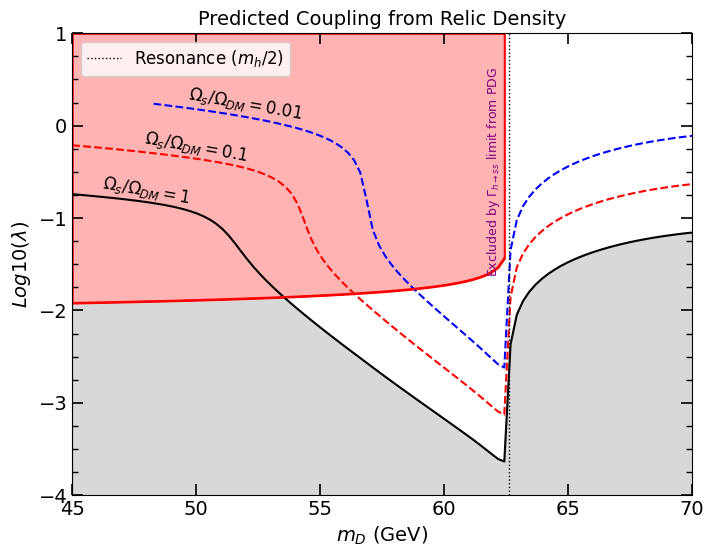

In [319]:
# Create a figure with standard academic proportions
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(masses_100,np.log10(couplings_100), color='black', linewidth=1.5)
ax.plot(masses_10,np.log10(couplings_10), color='red',linestyle = "--", linewidth=1.5)
ax.plot(masses_1,np.log10(couplings_1), color='blue',linestyle = "--", linewidth=1.5)
ax.fill_between(masses,y1=np.log10(couplings_100), y2= -4, alpha=0.3, color="gray")

ax.plot(masses,np.log10(Br_exclusion_limit), color='red', linewidth=1.5)
ax.fill_between(masses,y1=np.log10(Br_exclusion_limit), y2= 1, facecolor='#ffb3b3',  # A lighter pink/red for the inside
                 edgecolor='red',      # The solid border color for the whole shape
                 linewidth=1.5,        # Thickness of the border line
                 alpha=1.0)



# Set Logarithmic Scale on Y-axis
#plt.yscale('log')

# Formatting labels and limits to match the paper style
ax.set_xlabel(r'$m_D$ (GeV)', fontsize=14)
ax.set_ylabel(r'$Log10(\lambda)$', fontsize=14)
ax.set_title('Predicted Coupling from Relic Density', fontsize=14)

# Set limits similar to Figure 1 
ax.set_xlim(45, 70)
ax.set_ylim(-4, 1)
ax.axvline(x=m_h/2, color='black', linestyle=':', linewidth=1.0, label='Resonance ($m_h/2$)')
# Add grid and legend

# --- X-Axis Minor Ticks (from your current code) ---
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
ax.xaxis.set_minor_formatter(NullFormatter()) 

# --- Y-Axis Minor Ticks (NEW) ---
# This forces a minor tick every 0.25 units
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

# 2. Force ticks to point INWARD, be thicker, and appear on ALL FOUR sides
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, 
               bottom=True, top=True, left=True, right=True, labelsize=14)

# Because you already have this set up, your new Y-axis minor ticks 
# will automatically format correctly and point inward!
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0, 
               bottom=True, top=True, left=True, right=True)

# This will also automatically draw minor grid lines at those 0.25 intervals!
ax.grid(False)

plt.text(x=62, y=-0.5, 
         s=r"Excluded by $\Gamma_{h \to ss}$ limit from PDG", 
         fontsize=9, 
         color='purple', 
         ha='center', 
         va='center',
         rotation = 90)

plt.text(x=48, y=-0.7, 
         s=r"$\Omega_s/\Omega_{DM} = 1$", 
         fontsize=12, 
         color='black', 
         ha='center', 
         va='center',
         rotation = -10)

plt.text(x=50, y=-0.23, 
         s=r"$\Omega_s/\Omega_{DM} = 0.1$", 
         fontsize=12, 
         color='black', 
         ha='center', 
         va='center',
         rotation = -10)

plt.text(x=52, y=0.23, 
         s=r"$\Omega_s/\Omega_{DM} = 0.01$", 
         fontsize=12, 
         color='black', 
         ha='center', 
         va='center',
         rotation = -10)



ax.legend(fontsize=12)



# Save inside Results for your LaTeX includegraphics
path = output_dir / "higgs_Portal_strenght.png"

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Nucleon Spin Independent cross section $\sigma_{SI}^n$

In [268]:
############ EXPERIMENTAL DATA #################

#Load the data
output_dir = base_dir/ "Constraints"
output_dir.mkdir(parents=True, exist_ok=True)

#--------------------Xenon100 (2016)
path = output_dir / "HEPData-ins1463250-v1-Table_1.csv"
xenon100 = pd.read_csv(path, comment='#')
masses1, cs1 = xenon100["WIMP mass [GeV/$c^2$]"].tolist(), xenon100["WIMP-nucleon cross section [cm$^2$]"].tolist()

#-------------------LZ 2023
path = output_dir / "HEPData-ins2107834-v1-SI_cross_section.csv"
LZ_2023 = pd.read_csv(path, comment='#')

first_header_repeat = LZ_2023[LZ_2023['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_2023 = LZ_2023.iloc[:first_header_repeat[0]]

LZ_2023['mass'] = pd.to_numeric(LZ_2023['mass'], errors='coerce')
LZ_2023['pc_limit'] = pd.to_numeric(LZ_2023['pc_limit'], errors='coerce')
LZ_2023 = LZ_2023.dropna()
masses2, cs2 = LZ_2023["mass"].tolist(), LZ_2023["pc_limit"].tolist()

#--------------------LZ TONE YEARS 2025
path = output_dir / "HEPData-ins2841863-v2-SI_cross_section.csv"
LZ_TONE_YRS_2025 = pd.read_csv(path, comment='#')

first_header_repeat = LZ_TONE_YRS_2025[LZ_TONE_YRS_2025['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_TONE_YRS_2025 = LZ_TONE_YRS_2025.iloc[:first_header_repeat[0]]

LZ_TONE_YRS_2025['mass'] = pd.to_numeric(LZ_TONE_YRS_2025['mass'], errors='coerce')
LZ_TONE_YRS_2025['limit'] = pd.to_numeric(LZ_TONE_YRS_2025['limit'], errors='coerce')
LZ_TONE_YRS_2025 = LZ_TONE_YRS_2025.dropna()
masses3, cs3 = LZ_TONE_YRS_2025["mass"].tolist(), LZ_TONE_YRS_2025["limit"].tolist()

#-------------------LZ 2025
path = output_dir / "HEPData-ins3091049-v2-SI_cross_section.csv"
LZ_2025 = pd.read_csv(path, comment='#')

first_header_repeat = LZ_2025[LZ_2025['mass'] == 'mass'].index
if len(first_header_repeat) > 0:
    LZ_2025 = LZ_2025.iloc[:first_header_repeat[0]]

LZ_2025['mass'] = pd.to_numeric(LZ_2025['mass'], errors='coerce')
LZ_2025['limit'] = pd.to_numeric(LZ_2025['limit'], errors='coerce')
LZ_2025 = LZ_2025.dropna()
masses4, cs4 = LZ_2025["mass"].tolist(), LZ_2025["limit"].tolist()

#-------------------Storing in lists for nice plots
experimental_lines = [
    (masses1, cs1, "XENON100 (2016)", "blue"),
    (masses2, cs2, "LZ (2023)", "red"),
    (masses3, cs3, "LZ-TONNE-YRS (2025)", "green"),
    (masses4, cs4, "LZ (2025)", "purple"),
]

/tmp/ipykernel_5863/3900908701.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=12, frameon=True)


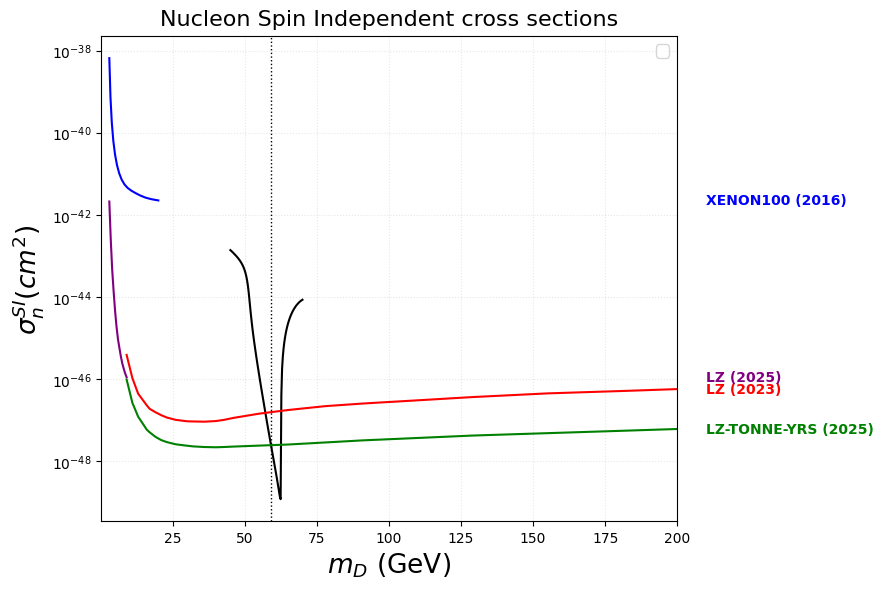

In [275]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses_100,cs_SI_n_100, color="black", linestyle="solid")

#Experimental data
for m, cs_exp, label, color in experimental_lines:
    line, = ax.plot(m, cs_exp, color=color, linestyle="solid")
    
    x_pos = 200
    y_pos = np.interp(200, m, cs_exp)
    
    ax.text(x_pos * 1.05, y_pos, label, color=color, 
            fontsize=10, va='center', fontweight='bold')

# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$\sigma_n^{SI} (cm^2) $", fontsize=19)
ax.set_title(r"Nucleon Spin Independent cross sections", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend
ax.legend(loc='upper right', fontsize=12, frameon=True)

plt.axvline(x=59, color='black', linestyle=':', linewidth=1.0)

# Save inside Results for your LaTeX includegraphics
output_dir = base_dir/ "Results"
output_dir.mkdir(parents=True, exist_ok=True)
path = output_dir / "Nucleon_SI_N_cs.png"

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [270]:
#####################Obtaining the available parameter space###################################

cs_SI_n_line = LineString(np.column_stack((masses, cs_SI_n)))
LZ_2025_line = LineString(np.column_stack((masses3, cs3)))

intersections = cs_SI_n_line.intersection(LZ_2025_line)

# This returns the exact geometric crossing point
# Extracting them individually
point_1 = intersections.geoms[0]
point_2 = intersections.geoms[1]


# Getting the x (mass) and y (cross section)
m1_norm, m2_norm = point_1.x, point_2.x

print(f"the available parameter space is: {round(m1_norm,3)} <= m_d <= {round(m2_norm,3)} GeV")

AttributeError: 'LineString' object has no attribute 'geoms'

### halo cross sections 

Using the couplings obtained from reproducing the relic abundance, we can compute the thermal average cross section at x = $3 \times 10^6$, which plays an important role at the annihilation in the galactic halo.

In [271]:
##############EXPERIMENTAL DATA######################
data = [
    {"n": 0, "x": 10.3126, "y": 1.061908e-28},
    {"n": 1, "x": 10.7668, "y": 1.077975e-28},
    {"n": 2, "x": 11.0352, "y": 1.077975e-28},
    {"n": 3, "x": 11.3103, "y": 1.094285e-28},
    {"n": 4, "x": 11.5923, "y": 1.094285e-28},
    {"n": 5, "x": 11.9547, "y": 1.094285e-28},
    {"n": 6, "x": 12.7924, "y": 1.127649e-28},
    {"n": 7, "x": 13.4382, "y": 1.144710e-28},
    {"n": 8, "x": 13.9439, "y": 1.162030e-28},
    {"n": 9, "x": 14.4686, "y": 1.197460e-28},
    {"n": 10, "x": 15.1991, "y": 1.233969e-28},
    {"n": 11, "x": 16.0651, "y": 1.290832e-28},
    {"n": 12, "x": 17.4037, "y": 1.391484e-28},
    {"n": 13, "x": 21.8561, "y": 2.183386e-28},
    {"n": 14, "x": 23.2440, "y": 2.537160e-28},
    {"n": 15, "x": 26.1284, "y": 3.084114e-28},
    {"n": 16, "x": 30.4759, "y": 3.748979e-28},
    {"n": 17, "x": 34.8964, "y": 4.557174e-28},
    {"n": 18, "x": 38.5089, "y": 5.216645e-28},
    {"n": 19, "x": 39.4691, "y": 5.375697e-28},
    {"n": 20, "x": 40.4531, "y": 5.623413e-28},
    {"n": 21, "x": 41.4617, "y": 5.882544e-28},
    {"n": 22, "x": 42.2346, "y": 6.061899e-28},
    {"n": 23, "x": 43.5549, "y": 6.534576e-28},
    {"n": 24, "x": 45.473, "y": 7.150688e-28},
    {"n": 25, "x": 46.6068, "y": 7.593374e-28},
    {"n": 26, "x": 47.7688, "y": 8.185467e-28},
    {"n": 27, "x": 48.6593, "y": 9.092758e-28},
    {"n": 28, "x": 49.5664, "y": 9.950069e-28},
    {"n": 29, "x": 53.367, "y": 1.384536e-27 },
    {"n": 30, "x": 54.3618, "y": 1.515077e-27},
    {"n": 31, "x": 54.6976, "y": 1.708475e-27},
    {"n": 32, "x": 55.7172, "y": 2.238721e-27},
    {"n": 33, "x": 56.4075, "y": 2.601461e-27},
    {"n": 34, "x": 57.1064, "y": 3.022977e-27},
    {"n": 35, "x": 58.5302, "y": 4.334675e-27},
    {"n": 36, "x": 61.1077, "y": 7.669775e-27},
    {"n": 37, "x": 62.6313, "y": 9.900387e-27},
    {"n": 38, "x": 64.1928, "y": 1.099776e-26},
    {"n": 39, "x": 65.7933, "y": 1.203469e-26},
    {"n": 40, "x": 67.8501, "y": 1.336863e-26},
    {"n": 41, "x": 71.7158, "y": 1.625061e-26},
    {"n": 42, "x": 77.6916, "y": 1.916941e-26},
    {"n": 43, "x": 84.6852, "y": 2.194342e-26},
    {"n": 44, "x": 88.9606, "y": 2.330190e-26},
    {"n": 45, "x": 99.3862, "y": 2.588472e-26},
    {"n": 46, "x": 106.35, "y": 2.707751e-26},
    {"n": 47, "x": 111.719, "y": 2.790308e-26},
    {"n": 48, "x": 120.286, "y": 2.832526e-26},
    {"n": 49, "x": 147.384, "y": 2.875383e-26},
    {"n": 50, "x": 154.824, "y": 2.832526e-26},
    {"n": 52, "x": 160.651, "y": 2.790308e-26},
    {"n": 53, "x": 169.803, "y": 2.707751e-26},
    {"n": 54, "x": 185.089, "y": 2.549892e-26},
    {"n": 55, "x": 194.433, "y": 2.437567e-26},
    {"n": 56, "x": 205.511, "y": 2.295459e-26},
    {"n": 57, "x": 218.561, "y": 2.129418e-26},
    {"n": 58, "x": 231.013, "y": 1.945944e-26},
    {"n": 59, "x": 244.175, "y": 1.751775e-26},
    {"n": 60, "x": 256.502, "y": 1.576980e-26},
    {"n": 61, "x": 271.116, "y": 1.377623e-26},
    {"n": 62, "x": 284.804, "y": 1.203469e-26},
    {"n": 63, "x": 291.904, "y": 1.099776e-26},
    {"n": 64, "x": 299.182, "y": 9.752825e-27},
    {"n": 65, "x": 306.642, "y": 8.648813e-27},
    {"n": 66, "x": 316.228, "y": 6.700188e-27},
    {"n": 67, "x": 328.128, "y": 5.269133e-27},
    {"n": 68, "x": 336.309, "y": 4.672671e-27},
    {"n": 69, "x": 342.578, "y": 4.081968e-27},
    {"n": 70, "x": 353.288, "y": 3.565939e-27},
    {"n": 71, "x": 364.332, "y": 3.068715e-27},
    {"n": 72, "x": 378.042, "y": 2.601461e-27},
    {"n": 73, "x": 392.268, "y": 2.205354e-27},
    {"n": 75, "x": 397.128, "y": 2.172484e-27},
    {"n": 76, "x": 412.072, "y": 2.108206e-27},
    {"n": 77, "x": 438.239, "y": 2.045830e-27},
    {"n": 78, "x": 451.939, "y": 2.015338e-27},
    {"n": 79, "x": 463.207, "y": 2.045830e-27},
    {"n": 80, "x": 480.638, "y": 2.076784e-27},
    {"n": 81, "x": 495.664, "y": 2.108206e-27},
    {"n": 82, "x": 520.688, "y": 2.172484e-27},
    {"n": 83, "x": 557.172, "y": 2.272593e-27},
    {"n": 84, "x": 574.59, "y": 2.341883e-27},
    {"n": 85, "x": 614.851, "y": 2.486865e-27},
    {"n": 86, "x": 653.895, "y": 2.640822e-27},
    {"n": 87, "x": 686.908, "y": 2.762513e-27},
    {"n": 88, "x": 735.039, "y": 2.977920e-27},
    {"n": 89, "x": 776.916, "y": 3.162278e-27},
    {"n": 90, "x": 806.152, "y": 3.307998e-27},
    {"n": 91, "x": 836.488, "y": 3.512790e-27},
    {"n": 92, "x": 889.606, "y": 3.902153e-27},
    {"n": 93, "x": 934.519, "y": 4.270068e-27},
    {"n": 94, "x": 981.7, "y": 4.743369e-27},
    {"n": 95, "x": 1037.63, "y": 5.348856e-27},
    {"n": 96, "x": 1096.75, "y": 6.122891e-27},
    {"n": 97, "x": 1159.23, "y": 7.008937e-27},
    {"n": 98, "x": 1225.28, "y": 7.903621e-27},
    {"n": 99, "x": 1295.09, "y": 8.912509e-27},
    {"n": 100, "x": 1368.87, "y": 1.005018e-26},
    {"n": 101, "x": 1455.8, "y": 1.133308e-26},
    {"n": 102, "x": 1538.74, "y": 1.258925e-26},
    {"n": 103, "x": 1719.07, "y": 1.530321e-26},
    {"n": 104, "x": 1862.32, "y": 1.751775e-26},
    {"n": 106, "x": 1956.34, "y": 1.916941e-26},
    {"n": 107, "x": 2080.57, "y": 2.129418e-26},
    {"n": 108, "x": 2240.1, "y": 2.437567e-26},
    {"n": 109, "x": 2338.75, "y": 2.667393e-26},
    {"n": 110, "x": 2456.83, "y": 2.963051e-26},
    {"n": 111, "x": 2596.8, "y": 3.291481e-26},
    {"n": 112, "x": 2744.75, "y": 3.711635e-26},
    {"n": 113, "x": 2901.13, "y": 4.185421e-26},
    {"n": 115, "x": 3047.59, "y": 4.580043e-26},
    {"n": 116, "x": 3301.54, "y": 5.242823e-26},
    {"n": 118, "x": 3446.94, "y": 5.651632e-26},
    {"n": 119, "x": 3620.96, "y": 6.001515e-26},
    {"n": 120, "x": 3803.77, "y": 6.469483e-26},
    {"n": 121, "x": 4120.72, "y": 7.186571e-26},
    {"n": 122, "x": 4491.66, "y": 7.864157e-26},
    {"n": 123, "x": 4776.88, "y": 8.477365e-26},
    {"n": 124, "x": 5080.22, "y": 9.002183e-26},
    {"n": 125, "x": 5503.53, "y": 9.559491e-26},
    {"n": 126, "x": 5925.53, "y": 1.015130e-25},
    {"n": 127, "x": 6340.73, "y": 1.077975e-25},
    {"n": 128, "x": 6826.92, "y": 1.127649e-25},
    {"n": 129, "x": 7817.14, "y": 1.233969e-25},
    {"n": 130, "x": 8313.54, "y": 1.271592e-25},
    {"n": 131, "x": 9230.83, "y": 1.350314e-25},
    {"n": 132, "x": 9696.86, "y": 1.370745e-25},
    {"n": 133, "x": 10061.8, "y": 1.370745e-25}
]
df_last = pd.DataFrame(data)   # data is your list of dicts
df_last = df_last.sort_values("x")

df_filtered = df_last[df_last['x'] <= 200].sort_values("x")

/tmp/ipykernel_5863/2278003725.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


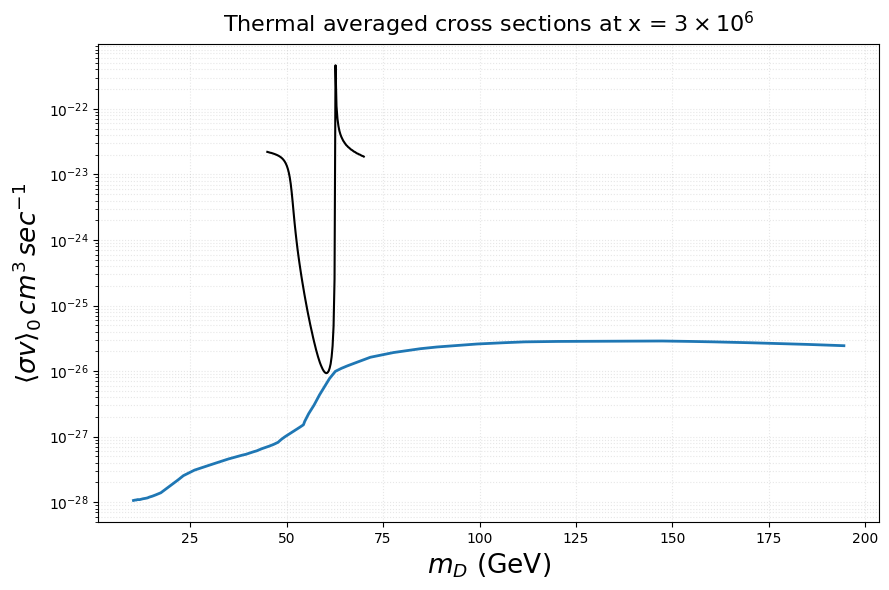

In [276]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses,cs_halo_100, color="black", linestyle="solid")
ax.plot(df_filtered["x"], df_filtered["y"], lw=2.0, label="Last dictionary")

# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$\langle \sigma v \rangle_0 \,  cm^3 \, sec^{-1}$", fontsize=19)
ax.set_title(r"Thermal averaged cross sections at x = $3 \times 10^6$", fontsize=16, pad=8)

# Limits
# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend


# Save inside Results for your LaTeX includegraphics
path = output_dir / "Halo_cs.png"

fig.savefig(path, dpi=300, bbox_inches="tight")
fig.tight_layout()
fig.show()

### Branching ratio

/tmp/ipykernel_5863/3545422108.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_5863/3545422108.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


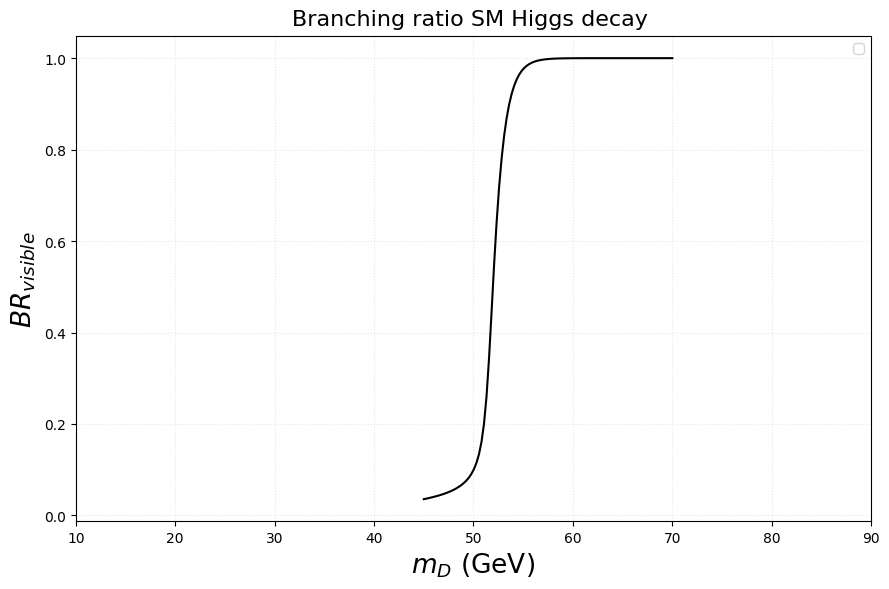

In [277]:
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(masses,Br_100, color="black", linestyle="solid")

# Axes labels and title
ax.set_xlabel(r"$m_D$ (GeV)", fontsize=19)
ax.set_ylabel(r"$BR_{visible}$", fontsize=19)
ax.set_title(r"Branching ratio SM Higgs decay ", fontsize=16, pad=8)

# Limits

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
# Legend
ax.set_xlim(10, 90)
ax.legend()

# Tight layout and save for LaTeX
# Save inside Results for your LaTeX includegraphics
path = output_dir / "Br.png"

fig.savefig(path, dpi=300, bbox_inches="tight")
fig.tight_layout()
fig.show()

# Safety checks

### Boltzmann equation solutions

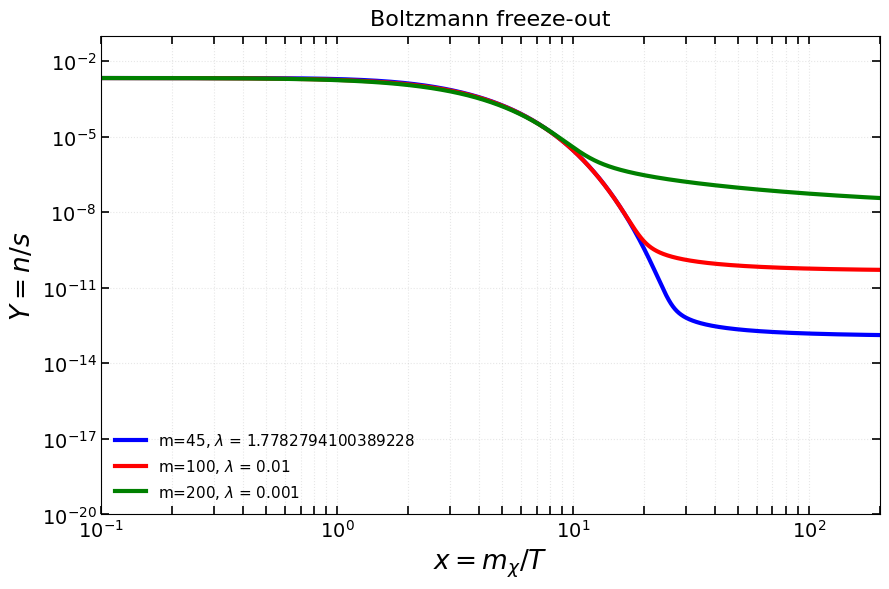

In [367]:
masses_test = [45,100,200]
lambda_test = [10**0.25,0.01,0.001]

x_test0, Y_0 = sol_boltz(masses_test[0],lambda_test[0])
x_test1, Y_1 = sol_boltz(masses_test[1],lambda_test[1])
x_test2, Y_2 = sol_boltz(masses_test[2],lambda_test[2])



# Use a single, clean figure
fig, ax = plt.subplots(figsize=(9, 6))

# Physical solution and equilibrium
ax.loglog(x_test0, Y_0,
          lw=3.0,
          label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]}", color="blue")

ax.loglog(x_test1, Y_1,
          lw=3.0,
          label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]}",color="red")

ax.loglog(x_test2, Y_2,
          lw=3.0,
          label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]}",color="green")

# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$Y = n/s$", fontsize=19)
ax.set_title(r"Boltzmann freeze-out", fontsize=16, pad=8)

# Limits
ax.set_xlim(0.1, 200)
ax.set_ylim(1e-20, 1e-1)

# Ticks: size and style
ax.tick_params(axis="both", which="both",
               direction="in",
               length=6, width=1.2,
               labelsize=14,
               top=True, right=True)

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)

# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\safety_checks\Boltz_solutions"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Thermal Averaged cross sections (Interpolation)

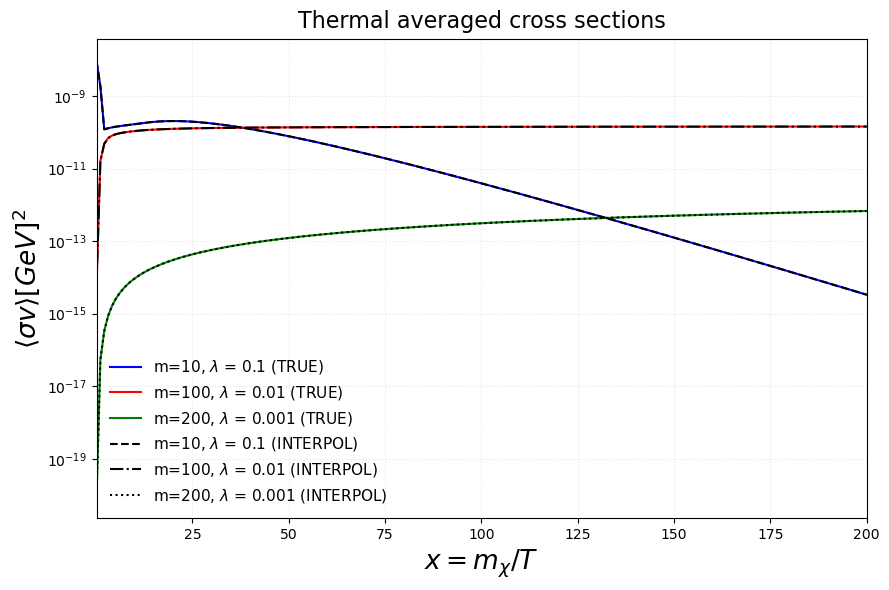

In [85]:
masses_test = [10,100,200]
lambda_test = [0.1,0.01,0.001]

#Storing results
sig_true0 = []
sig_true1 = []
sig_true2 = []

sig_interp0 = []
sig_interp1 = []
sig_interp2 = []
#Range of x to test
x_min_test, x_max_test = 0.1, 200
x_test = np.linspace(x_min_test, x_max_test,200)

#Generating true sigmas
for x_val in x_test:
    sig_true0.append(thermal_avg_cs(lambda_test[0], masses_test[0], masses_test[0]/x_val))
    sig_true1.append(thermal_avg_cs(lambda_test[1], masses_test[1], masses_test[1]/x_val))
    sig_true2.append(thermal_avg_cs(lambda_test[2], masses_test[2], masses_test[2]/x_val))

#Generating interpolated sigmas
f0 = interpol_sigma(lambda_test[0], masses_test[0], x_min_test, x_max_test)
f1 = interpol_sigma(lambda_test[1], masses_test[1], x_min_test, x_max_test)
f2 = interpol_sigma(lambda_test[2], masses_test[2], x_min_test, x_max_test)

sig_interp0 = 10**(f0(masses_test[0]/x_test))
sig_interp1 = 10**(f1(masses_test[1]/x_test))
sig_interp2 = 10**(f2(masses_test[2]/x_test))

#--------------------Ploting-----------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
#True sigmas
ax.plot(x_test,sig_true0, color="blue", linestyle="solid",label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]} (TRUE)")
ax.plot(x_test,sig_true1, color="red", linestyle="solid",label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]} (TRUE)")
ax.plot(x_test,sig_true2, color="green", linestyle="solid",label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]} (TRUE)")

#Interpoled sigmas 
ax.plot(x_test,sig_interp0, color="black", linestyle="--",label=fr"m={masses_test[0]}, $\lambda$ = {lambda_test[0]} (INTERPOL)")
ax.plot(x_test,sig_interp1, color="black", linestyle="-.",label=fr"m={masses_test[1]}, $\lambda$ = {lambda_test[1]} (INTERPOL)")
ax.plot(x_test,sig_interp2, color="black", linestyle=":",label=fr"m={masses_test[2]}, $\lambda$ = {lambda_test[2]} (INTERPOL)")

# Axes labels and title
ax.set_xlabel(r"$x = m_\chi/T$", fontsize=19)
ax.set_ylabel(r"$\langle \sigma v \rangle [GeV]^2$", fontsize=19)
ax.set_title(r"Thermal averaged cross sections", fontsize=16, pad=8)

# Limits
ax.set_xlim(x_min_test, x_max_test)

# Light grid for readability
ax.grid(True, which="both", ls=":", alpha=0.3)
ax.set_yscale("log")
# Legend
ax.legend(loc="lower left",
          fontsize=11,
          frameon=False)

# Tight layout and save for LaTeX
fig.tight_layout()


# Save inside Images/ for your LaTeX includegraphics
path = r"C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\safety_checks\thermal_avg_cs_interpol"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

### Degrees of freedom (interpolation)

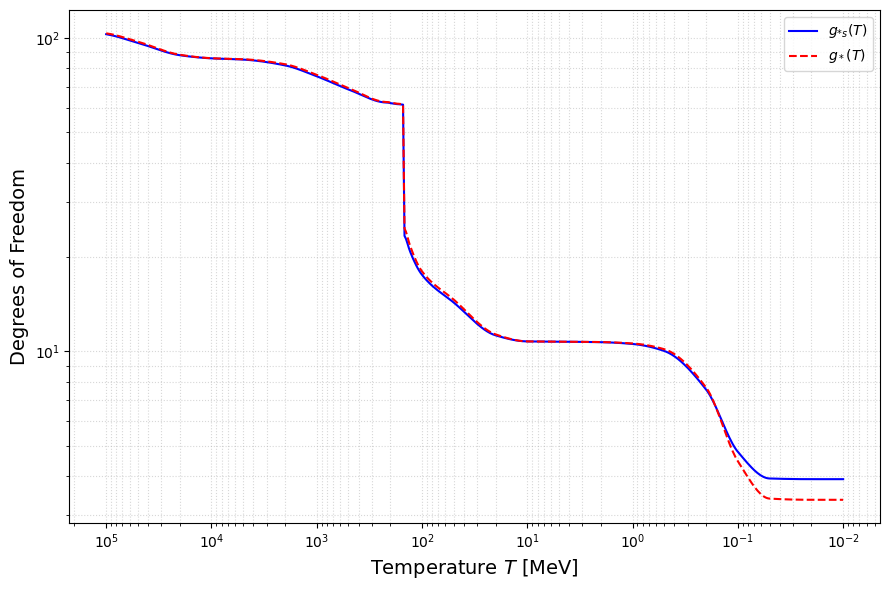

In [32]:
#--------Checking degrees of freedom-------
test_mass = 10
x_range = np.logspace(np.log10(0.1),np.log10(1000000),500)
T_test = test_mass/x_range

h_test = 10**(h_eff_log(np.log10(T_test)))
g_test = 10**(g_eff_log(np.log10(T_test)))


fig, ax = plt.subplots(figsize=(9, 6))

#-----------Ploting--------------
ax.plot(T_test*1E3, h_test, color="blue", label=r"$g_{*s}(T)$")
ax.plot(T_test*1E3, g_test, color="red", linestyle="--", label=r"$g_*(T)$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Temperature $T$ [MeV]", fontsize=14)
ax.set_ylabel(r"Degrees of Freedom", fontsize=14)
ax.invert_xaxis() # High T on the left (Early Universe)
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()

# Save inside Results for your LaTeX includegraphics
output_dir = base_dir/ "Results" / "safety_checks"
output_dir.mkdir(parents=True, exist_ok=True)
path = output_dir / "DOF_interpolation.png"

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Higgs decay width to SM 

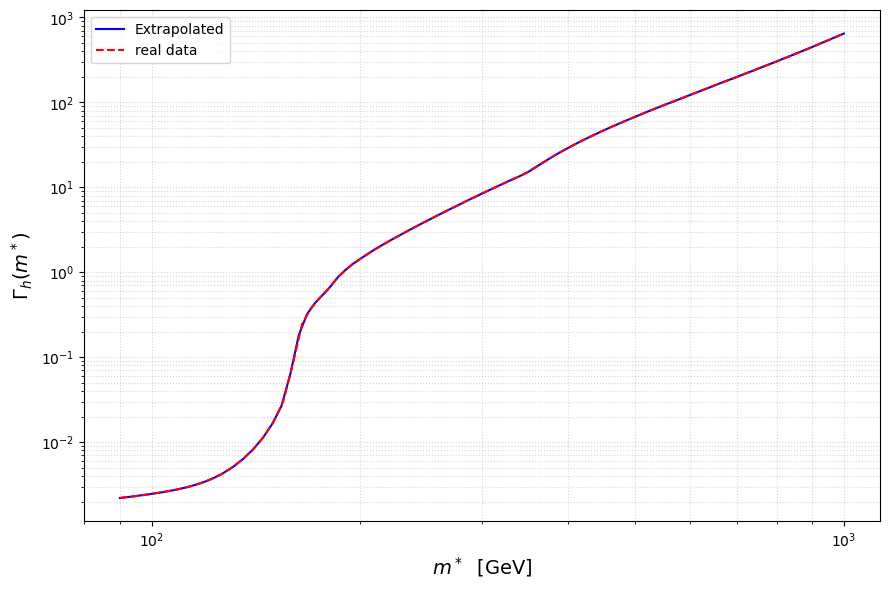

In [ ]:
#--------Checking degrees of freedom-------
x_range = np.linspace(90,1E3,200)
y_range = SM_width(x_range) 

fig, ax = plt.subplots(figsize=(9, 6))

#-----------Ploting--------------
ax.plot(x_range, y_range, color="blue", label=r"Extrapolated")
ax.plot(s_data, width_data, color="red", linestyle="--", label=r"real data")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m^*$  [GeV]", fontsize=14)
ax.set_ylabel(r"$\Gamma_h(m^*)$", fontsize=14)
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()

# Save inside Results for your LaTeX includegraphics
output_dir = base_dir/ "Results" / "safety_checks"
output_dir.mkdir(parents=True, exist_ok=True)
path = output_dir / "higgs_Decay_Width_to_SM.png"

plt.savefig(path, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### comparing native python vs joblib

In [ ]:
#python native method
masses = np.linspace(10,200,100)
couplings_native = [couplings(md) for md in masses]

# Store the data
df = pd.DataFrame({'masses': masses, 'Portal_Coupling': couplings_native})
output_file = r"C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\data_native.csv"
df.to_csv(output_file, index=False)

print(f"Success! Data saved to {output_file}")

###############JOBLIB METHOD###############
print(f"Starting evaluation across {len(masses)} points using multiple cores...")

# Joblib code + Progress bar
with tqdm_joblib(tqdm(desc="Calculating Portal Couplings", total=len(masses), ncols=80)):
    results = Parallel(n_jobs=-1)(
        delayed(coupling)(m_d) for m_d in masses
    )

# Store the data
df = pd.DataFrame({'masses': masses, 'Portal_Coupling': results})
output_file = r"C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\data_joblib.csv"
df.to_csv(output_file, index=False)

print(f"Success! Data saved to {output_file}")

In [ ]:
#Loading each results

native_data = pd.read_csv(r'C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\data_native')
native_masses = native_data.iloc[:,0]
native_couplings = native_data.iloc[:,1]

joblib_data = pd.read_csv(r'C:\Users\eetth\OneDrive\Escritorio\uni\Real-Scalar-Singlet-Revisited\Results\data_joblib')
joblib_masses = joblib_data.iloc[:,0]
joblib_couplings = joblib_data.iloc[:,1]

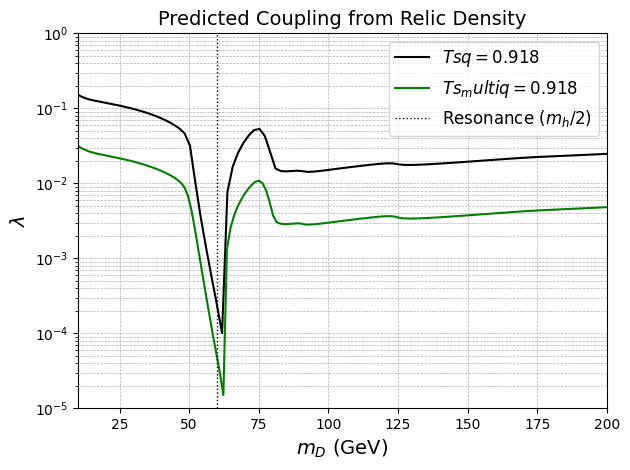

In [ ]:
#Showing couplings

plt.plot(native_masses,native_couplings, color='Blue', linewidth=1.5, label=f'$native$')
plt.plot(joblib_masses,joblib_couplings, color='black', linewidth=1.5, label =f'$joblib')

# Set Logarithmic Scale on Y-axis
plt.yscale('log')

# Formatting labels and limits to match the paper style
plt.xlabel(r'$m_D$ (GeV)', fontsize=14)
plt.ylabel(r'$\lambda$', fontsize=14)
plt.title('Predicted Coupling from Relic Density', fontsize=14)

# Set limits similar to Figure 1 
plt.xlim(10, 200)  # Adjust lower limit if your resonance dip goes deeper
plt.ylim(1e-5, 1.0)
plt.axvline(x=60, color='black', linestyle=':', linewidth=1.0, label='Resonance ($m_h/2$)')
# Add grid and legend
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Show the plot

plt.tight_layout()
plt.savefig(r'/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/comparing_methods')
plt.show()

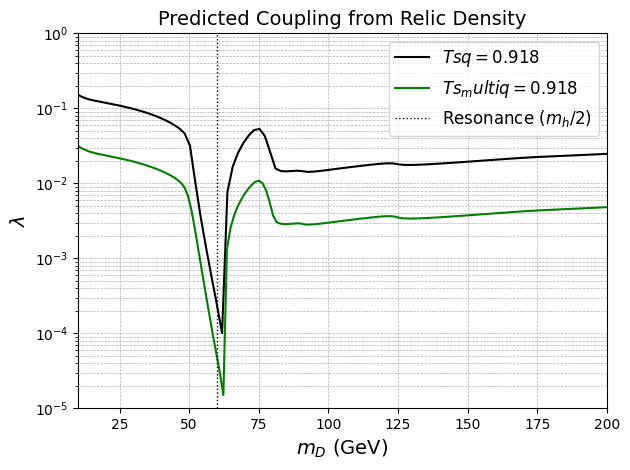

In [ ]:
#Showing couplings

plt.plot(native_masses,native_couplings-joblib_couplings, color='Blue', linewidth=1.5, label=f'$diference$')

# Set Logarithmic Scale on Y-axis
plt.yscale('log')

# Formatting labels and limits to match the paper style
plt.xlabel(r'$m_D$ (GeV)', fontsize=14)
plt.ylabel(r'$\lambda$', fontsize=14)
plt.title('Difference in the prediction for both methods', fontsize=14)

# Set limits similar to Figure 1 
plt.xlim(10, 200)  # Adjust lower limit if your resonance dip goes deeper
plt.ylim(1e-5, 1.0)
plt.axvline(x=60, color='black', linestyle=':', linewidth=1.0, label='Resonance ($m_h/2$)')
# Add grid and legend
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)

# Show the plot

plt.tight_layout()
plt.savefig(r'/home/ethan/repos/DM-tsallis-q-statistics/Plots/Safety_checks/comparing_methods_difference')
plt.show()